# CDSS RAG Pipeline — Evaluation Walkthrough

This notebook walks through the evaluation framework for the Clinical Decision Support System (CDSS) RAG pipeline.  
It covers:

1. **Setup** — connect to ChromaDB, load the evaluators  
2. **Retrieval eval** — RAG vector search vs keyword baseline  
3. **Live query demos** — run example queries on real patients  
4. **Generation eval** — ROUGE, BERTScore, faithfulness  
5. **Results summary** — load saved JSON/CSV and visualise  

All patient data is from MIMIC-IV discharge notes. The **10 held-out patients** (last 10 `subject_id`s by sorted order in the `cdss_147` collection) are used as the eval ground-truth set.

## 1 · Setup

In [31]:
import sys, os

# ── Set this if auto-detection fails ────────────────────────────────────────
MANUAL_ROOT = "/Users/pratik/Desktop/projects/cdss"
# ────────────────────────────────────────────────────────────────────────────

def _find_project_root(start: str) -> str:
    """Walk up directory tree looking for config/settings.py as a landmark."""
    current = os.path.abspath(start)
    for _ in range(8):
        if os.path.exists(os.path.join(current, "config", "settings.py")):
            return current
        parent = os.path.dirname(current)
        if parent == current:   # reached filesystem root
            break
        current = parent
    raise RuntimeError("Could not auto-detect project root.")

try:
    ROOT = _find_project_root(os.getcwd())
except RuntimeError:
    ROOT = MANUAL_ROOT
    if not os.path.exists(os.path.join(ROOT, "config", "settings.py")):
        raise RuntimeError(f"Project root not found at '{ROOT}'. Update MANUAL_ROOT above.")

os.chdir(ROOT)
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

print(f"Project root: {ROOT}")

import warnings
warnings.filterwarnings("ignore")

import chromadb
from chromadb.config import Settings
from collections import defaultdict
from config.settings import settings

client = chromadb.PersistentClient(
    path=os.path.join(ROOT, "chroma_db"),
    settings=Settings(anonymized_telemetry=False),
)
collection = client.get_collection("cdss_147")
print(f"Connected to cdss_147 — {collection.count()} chunks")

Project root: /Users/pratik/Desktop/projects/cdss
Connected to cdss_147 — 1193 chunks


In [32]:
# Quick inventory of what's in the collection
all_docs = collection.get(include=["metadatas"], limit=collection.count())

patients = defaultdict(set)
for m in all_docs["metadatas"]:
    patients[m["patient_id"]].add(m["hadm_id"])

print(f"Unique patients : {len(patients)}")
print(f"Unique admissions: {sum(len(v) for v in patients.values())}")
print(f"\nFirst 5 patients and their admission count:")
for pid in sorted(patients)[:5]:
    print(f"  subject_id={pid}  admissions={len(patients[pid])}")

Unique patients : 30
Unique admissions: 93

First 5 patients and their admission count:
  subject_id=10000032  admissions=4
  subject_id=10000084  admissions=1
  subject_id=10000117  admissions=2
  subject_id=10000248  admissions=1
  subject_id=10000560  admissions=1


## 2 · Retrieval Evaluation

We compare three retrieval strategies for each of the 20 eval queries:

| Strategy | Description |
|---|---|
| **RAG (global)** | Embed query → cosine search across all 1,193 chunks — no patient filter |
| **RAG (scoped)** | Same vector search but filtered to `query.hadm_id` — mirrors the app's "Single patient" mode |
| **Keyword** | Score every chunk by keyword hit count globally, take top-5 |

A retrieved chunk is a **true positive** if `hadm_id` and `section` both match the query's ground truth.

**Why scoped matters:** patient-specific queries ("What is *this patient's* diagnosis?") contain no identifier — global vector search will surface the most semantically similar chunk from any patient. Scoped retrieval constrains the search to the correct admission, making section selection the only remaining challenge.

In [33]:
from eval.retrieval_eval import RetrievalEvaluator
from eval.query_set import QUERY_SET, HELD_OUT_SUBJECT_IDS

print(f"Held-out patients: {HELD_OUT_SUBJECT_IDS}")
print(f"Eval queries     : {len(QUERY_SET)}")

Held-out patients: ['10001884', '10001919', '10002013', '10002131', '10002155', '10002167', '10002221', '10002348', '10002428', '10002430']
Eval queries     : 20


In [34]:
ret_evaluator = RetrievalEvaluator()
ret_results   = ret_evaluator.run()
ret_agg       = RetrievalEvaluator.aggregate(ret_results)

[RetrievalEvaluator] Connected to 'cdss_147' (1193 docs)
[RetrievalEvaluator] Fetching all chunks for keyword baseline...
[RetrievalEvaluator] Cached 1193 chunks
  Q01 | RAG P=0.00 R=0.00 | Scoped P=0.20 R=1.00 | KW P=0.00 R=0.00 | relevant=1
  Q02 | RAG P=0.00 R=0.00 | Scoped P=0.20 R=1.00 | KW P=0.20 R=1.00 | relevant=1
  Q03 | RAG P=0.00 R=0.00 | Scoped P=0.20 R=1.00 | KW P=0.20 R=1.00 | relevant=1
  Q04 | RAG P=0.00 R=0.00 | Scoped P=0.20 R=1.00 | KW P=0.20 R=1.00 | relevant=1
  Q05 | RAG P=0.00 R=0.00 | Scoped P=0.20 R=1.00 | KW P=0.00 R=0.00 | relevant=1
  Q06 | RAG P=0.00 R=0.00 | Scoped P=0.20 R=1.00 | KW P=0.20 R=1.00 | relevant=1
  Q07 | RAG P=0.00 R=0.00 | Scoped P=0.20 R=1.00 | KW P=0.20 R=1.00 | relevant=1
  Q08 | RAG P=0.00 R=0.00 | Scoped P=0.20 R=1.00 | KW P=0.20 R=1.00 | relevant=1
  Q09 | RAG P=0.00 R=0.00 | Scoped P=0.20 R=1.00 | KW P=0.00 R=0.00 | relevant=1
  Q10 | RAG P=0.00 R=0.00 | Scoped P=0.20 R=1.00 | KW P=0.20 R=1.00 | relevant=1
  Q11 | RAG P=0.00 R=0.00 | 

In [35]:
import pandas as pd

ret_df = pd.DataFrame([
    {
        "Query ID":   r.query_id,
        "Section":    r.expected_section,
        "Relevant":   r.total_relevant,
        "RAG P":      round(r.rag_precision,    2),
        "RAG R":      round(r.rag_recall,       2),
        "Scoped P":   round(r.scoped_precision, 2),
        "Scoped R":   round(r.scoped_recall,    2),
        "KW P":       round(r.kw_precision,     2),
        "KW R":       round(r.kw_recall,        2),
    }
    for r in ret_results
])

display(ret_df.style.background_gradient(
    subset=["RAG P", "RAG R", "Scoped P", "Scoped R", "KW P", "KW R"],
    cmap="RdYlGn"
))

,Query ID,Section,Relevant,RAG P,RAG R,Scoped P,Scoped R,KW P,KW R
0,Q01,discharge_diagnosis,1,0.000000,0.000000,0.200000,1.000000,0.000000,0.000000
1,Q02,discharge_medications,1,0.000000,0.000000,0.200000,1.000000,0.200000,1.000000
2,Q03,discharge_diagnosis,1,0.000000,0.000000,0.200000,1.000000,0.200000,1.000000
3,Q04,medications_on_admission,1,0.000000,0.000000,0.200000,1.000000,0.200000,1.000000
4,Q05,allergies,1,0.000000,0.000000,0.200000,1.000000,0.000000,0.000000
5,Q06,discharge_medications,1,0.000000,0.000000,0.200000,1.000000,0.200000,1.000000
6,Q07,allergies,1,0.000000,0.000000,0.200000,1.000000,0.200000,1.000000
7,Q08,discharge_diagnosis,1,0.000000,0.000000,0.200000,1.000000,0.200000,1.000000
8,Q09,allergies,1,0.000000,0.000000,0.200000,1.000000,0.000000,0.000000
9,Q10,history_of_present_illness,1,0.000000,0.000000,0.200000,1.000000,0.200000,1.000000


In [36]:
print("── Aggregate Retrieval Metrics ──")
for k, v in ret_agg.items():
    if k != "n_queries":
        print(f"  {k:<28}: {v:.3f}")

── Aggregate Retrieval Metrics ──
  rag_mean_precision          : 0.020
  rag_mean_recall             : 0.100
  scoped_mean_precision       : 0.190
  scoped_mean_recall          : 0.950
  kw_mean_precision           : 0.160
  kw_mean_recall              : 0.800


## 3 · Live Query Demos

Let's run a few example queries interactively to see what the pipeline actually retrieves and generates.

In [37]:
from modules.embedding import EmbeddingModule
from modules.generation import GenerationModule

embedder  = EmbeddingModule()
generator = GenerationModule()

In [38]:
def run_query(query: str, hadm_id: str | None = None, n_results: int = 5):
    """End-to-end RAG: retrieve → generate. Optionally scope to one admission."""
    vec     = embedder.embed_query(query)
    where   = {"hadm_id": hadm_id} if hadm_id else None
    results = collection.query(
        query_embeddings=[vec],
        n_results=n_results,
        where=where,
        include=["documents", "metadatas", "distances"],
    )
    chunks = [
        {
            "text":     results["documents"][0][i],
            "metadata": results["metadatas"][0][i],
            "score":    1 - results["distances"][0][i],
        }
        for i in range(len(results["ids"][0]))
    ]

    answer = generator.process({"query": query, "context_chunks": chunks})

    print(f"Query : {query}")
    if hadm_id:
        print(f"Scoped to HADM: {hadm_id}")
    print()
    print("── Retrieved chunks ─────────────────────────────────────────")
    for i, c in enumerate(chunks, 1):
        section = c["metadata"]["section"].replace("_", " ").title()
        print(f"  [{i}] hadm={c['metadata']['hadm_id']}  section={section}  "
              f"score={c['score']:.3f}")
        print(f"      {c['text'][:150]}...")
    print()
    print("── Generated answer ─────────────────────────────────────────")
    print(answer)
    return chunks, answer

### Demo 1 — Allergies query (held-out patient 10002013, HADM 21763296)

In [39]:
chunks, answer = run_query(
    "Does this patient have any documented drug allergies?",
    hadm_id="21763296",
)

Query : Does this patient have any documented drug allergies?
Scoped to HADM: 21763296

── Retrieved chunks ─────────────────────────────────────────
  [1] hadm=21763296  section=Medications On Admission  score=0.672
      The Preadmission Medication list is accurate and complete. 1. Losartan Potassium 25 mg PO DAILY 2. MetronidAZOLE Topical 1 % Gel 1 Appl TP BID:PRN Ros...
  [2] hadm=21763296  section=Pertinent Results  score=0.653
      female with CAD(s/p BMS proximal-LAD , DES to mid LAD , DES to edge ISR of mid LAD DES and stenosis distal to stent , DES to , s/p 3 v CABG LIMA-LAD, ...
  [3] hadm=21763296  section=Discharge Medications  score=0.647
      1. Ciprofloxacin HCl 500 mg PO Q12H RX *ciprofloxacin HCl 500 mg 1 tablet(s) by mouth twice a day Disp #*14 Tablet Refills:*0 2. Clindamycin 300 mg PO...
  [4] hadm=21763296  section=Allergies  score=0.647
      lisinopril Attending:...
  [5] hadm=21763296  section=Pertinent Results  score=0.613
      was stopped due to increased r

### Demo 2 — Discharge diagnosis (held-out patient 10002430, HADM 24513842)

In [40]:
chunks, answer = run_query(
    "What is this patient's primary discharge diagnosis?",
    hadm_id="24513842",
)

Query : What is this patient's primary discharge diagnosis?
Scoped to HADM: 24513842

── Retrieved chunks ─────────────────────────────────────────
  [1] hadm=24513842  section=Discharge Diagnosis  score=0.733
      Primary: Acute on chronic diastolic congestive heart failure Cor pulmonale Secondary: Pulmonary hypertension Paroxysmal atrial fibrillation Hyponatrem...
  [2] hadm=24513842  section=Discharge Instructions  score=0.675
      Dear Mr. , You were hospitalized for progressive leg swelling over the past week and a half. We started you on a new medication here that should help ...
  [3] hadm=24513842  section=Discharge Condition  score=0.662
      Mental Status: Clear and coherent. Level of Consciousness: Alert and interactive. Activity Status: Ambulatory - Independent....
  [4] hadm=24513842  section=History Of Present Illness  score=0.658
      HISTORY OF PRESENTING ILLNESS: Mr. is an year old gentleman with history of CAD (s/p 3V CABG , LM PCI , pulmonary HTN, AFib on anticoa

### Demo 3 — Medications across all patients (global retrieval, no HADM filter)

In [41]:
chunks, answer = run_query(
    "Which patients were prescribed amiodarone and what were their diagnoses?"
)

Query : Which patients were prescribed amiodarone and what were their diagnoses?

── Retrieved chunks ─────────────────────────────────────────
  [1] hadm=24513842  section=Pertinent Results  score=0.740
      scheduled outpatient appointment. #Atrial Fibrillation: Continue home amiodarone 200mg daily, Apixaban 5mg BID #CAD: Continue ASA 81mg, rosuvastatin 4...
  [2] hadm=29678536  section=Pertinent Results  score=0.718
      prompting her referral to the ED. Her COPD exacerbation was the likely precipitant, with medications also possibly contributing, particularly theophyl...
  [3] hadm=24962904  section=History Of Present Illness  score=0.716
      Ms. is a female with history of COPD on home O2, atrial fibrillation on apixaban, hypertension, CAD, and hyperlipidemia who presents with shortness of...
  [4] hadm=26184834  section=History Of Present Illness  score=0.708
      with COPD who has been admitted 9 times since for dyspnea, CAD, atrial fibrillation on apixaban who presented wi

### Demo 4 — History of present illness (held-out patient 10002348, HADM 22725460)

In [42]:
chunks, answer = run_query(
    "What were this patient's presenting symptoms and reason for admission?",
    hadm_id="22725460",
)

Query : What were this patient's presenting symptoms and reason for admission?
Scoped to HADM: 22725460

── Retrieved chunks ─────────────────────────────────────────
  [1] hadm=22725460  section=History Of Present Illness  score=0.675
      is a female with hx cerebral aneurysm clipping in who presents from OSH with left cerebellar hypodensity concerning for underlying lesion. Patient rep...
  [2] hadm=22725460  section=Pertinent Results  score=0.647
      urgency and increased frequency. U/A was negative and culture was negative. Her symptoms had resolved at the time of discharge. #Dispo The patient was...
  [3] hadm=22725460  section=Pertinent Results  score=0.628
      Please see OMR for pertinent lab and imaging results. Brief Hospital Course: #Brain lesion Patient was found to have cerebellar hypodensity on NCHCT f...
  [4] hadm=22725460  section=Discharge Instructions  score=0.625
      common. - Constipation is common. Be sure to drink plenty of fluids and eat a high-fiber diet

## 4 · Generation Evaluation

For each query we compare:
- **RAG** — top-5 chunks retrieved **scoped to `query.hadm_id`** → `llama3.2:3b` with de-identification-aware prompt  
- **No-RAG** — same query sent to `llama3.2:3b` with no patient records, instructed to answer from general medical knowledge

**Reference text:** the full text of the ground-truth chunk (hadm_id + expected_section) looked up directly from ChromaDB — not just keywords. All 20/20 queries resolve to a real chunk reference.

**Faithfulness scoring:** fraction of response sentences containing at least one content-specific token from the retrieved chunks (stopwords and generic clinical prose excluded). Scores below 0.5 are flagged.

**MIMIC-IV de-identification note:** patient ages, names, and dates are removed in MIMIC-IV, leaving fragments like `"year old female"`. The generation prompt explicitly instructs the model to treat these as valid clinical content rather than refuse to answer.

In [43]:
# If the generation eval has already been run via run_eval.py, load from disk.
# Otherwise uncomment the block below to run it here (slow — ~10 min).

import json, pathlib

results_path = pathlib.Path(ROOT) / "eval" / "results" / "eval_results.json"

if results_path.exists():
    with open(results_path) as f:
        saved = json.load(f)
    gen_data = saved.get("generation", [])
    print(f"Loaded {len(gen_data)} generation results from disk.")
else:
    print("No saved results found. Run the cell below to generate them.")
    gen_data = []

Loaded 20 generation results from disk.


In [44]:
# ── Uncomment to run generation eval live (requires Ollama) ──
# from eval.generation_eval import GenerationEvaluator
# gen_evaluator = GenerationEvaluator()
# gen_results   = gen_evaluator.run()
# gen_agg       = GenerationEvaluator.aggregate(gen_results)
# gen_data = [vars(r) for r in gen_results]

In [45]:
if gen_data:
    gen_df = pd.DataFrame([
        {
            "ID":            r["query_id"],
            "Ref source":    r.get("reference_source", "?"),
            "RAG ROUGE-1":   round(r["rag_rouge1"], 3),
            "RAG ROUGE-2":   round(r["rag_rouge2"], 3),
            "RAG ROUGE-L":   round(r["rag_rougeL"], 3),
            "RAG BERTScore": round(r["rag_bertscore"], 3),
            "RAG Faith":     round(r["rag_faithfulness"], 3),
            "NR ROUGE-1":    round(r["norag_rouge1"], 3),
            "NR ROUGE-2":    round(r["norag_rouge2"], 3),
            "NR ROUGE-L":    round(r["norag_rougeL"], 3),
            "NR BERTScore":  round(r["norag_bertscore"], 3),
            "Flag":          "⚠" if r["rag_faithfulness_flag"] else "✓",
        }
        for r in gen_data
    ])

    n_chunk = (gen_df["Ref source"] == "chunk").sum()
    print(f"Reference source: {n_chunk}/{len(gen_df)} queries used real chunk text")

    display(gen_df.style.background_gradient(
        subset=["RAG ROUGE-1", "RAG ROUGE-2", "RAG ROUGE-L",
                "RAG BERTScore", "RAG Faith",
                "NR ROUGE-1", "NR BERTScore"],
        cmap="RdYlGn"
    ))
else:
    print("Run the generation eval first.")

Reference source: 20/20 queries used real chunk text


,ID,Ref source,RAG ROUGE-1,RAG ROUGE-2,RAG ROUGE-L,RAG BERTScore,RAG Faith,NR ROUGE-1,NR ROUGE-2,NR ROUGE-L,NR BERTScore,Flag
0,Q01,chunk,0.240000,0.174000,0.240000,0.898000,0.500000,0.000000,0.000000,0.000000,0.816000,✓
1,Q02,chunk,0.157000,0.108000,0.135000,0.822000,1.000000,0.021000,0.000000,0.014000,0.766000,✓
2,Q03,chunk,0.526000,0.471000,0.526000,0.879000,1.000000,0.000000,0.000000,0.000000,0.786000,✓
3,Q04,chunk,0.497000,0.206000,0.420000,0.857000,1.000000,0.074000,0.000000,0.059000,0.779000,✓
4,Q05,chunk,0.087000,0.000000,0.087000,0.841000,0.500000,0.000000,0.000000,0.000000,0.781000,✓
5,Q06,chunk,0.039000,0.007000,0.039000,0.786000,1.000000,0.031000,0.000000,0.025000,0.749000,✓
6,Q07,chunk,0.923000,0.909000,0.923000,0.976000,1.000000,0.000000,0.000000,0.000000,0.778000,✓
7,Q08,chunk,0.370000,0.269000,0.370000,0.856000,1.000000,0.097000,0.000000,0.065000,0.787000,✓
8,Q09,chunk,0.182000,0.000000,0.182000,0.830000,1.000000,0.000000,0.000000,0.000000,0.793000,✓
9,Q10,chunk,0.501000,0.309000,0.393000,0.880000,1.000000,0.066000,0.007000,0.051000,0.791000,✓


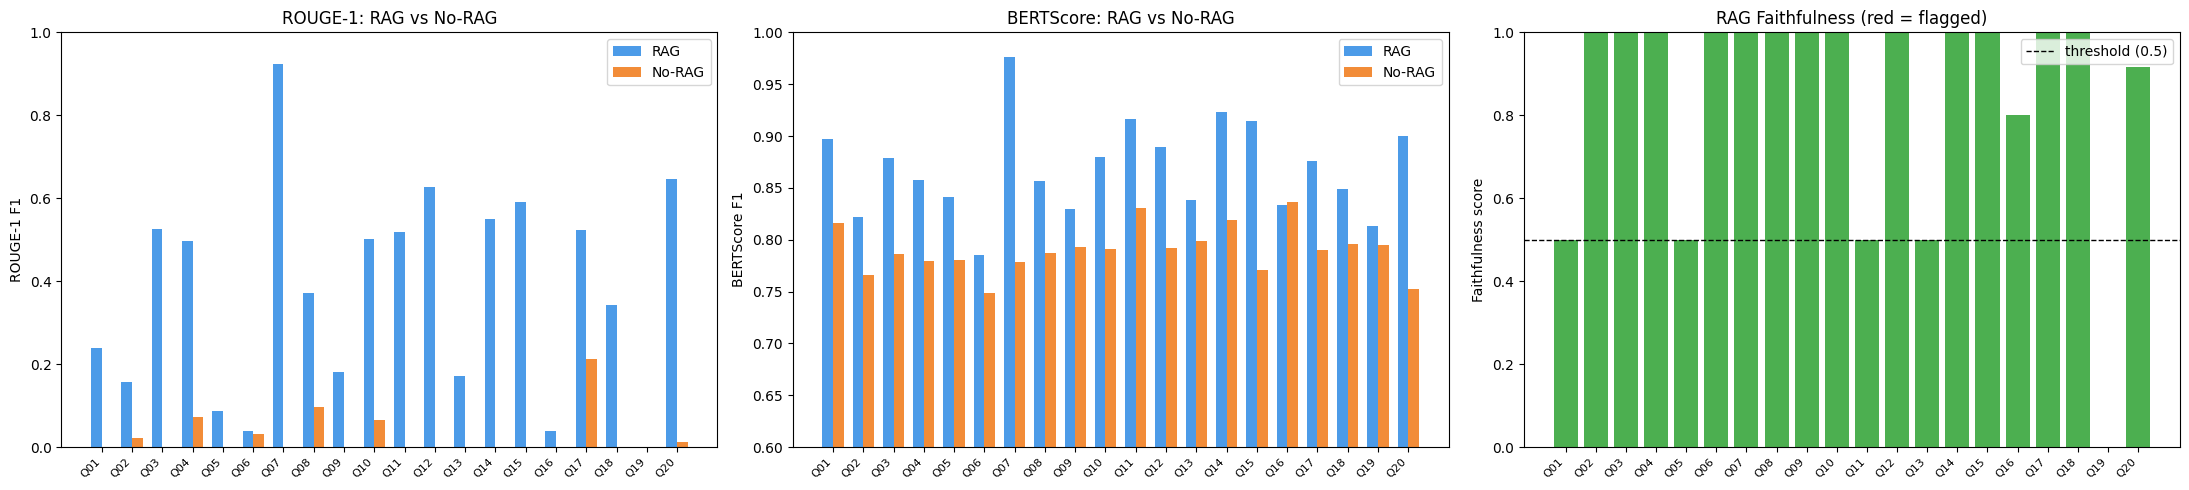


Mean RAG ROUGE-1  : 0.377
Mean NR  ROUGE-1  : 0.026  (delta: +0.351)
Mean RAG BERTScore: 0.869
Mean NR  BERTScore: 0.790  (delta: +0.079)


In [46]:
if gen_data:
    import matplotlib.pyplot as plt
    import numpy as np

    ids        = [r["query_id"]           for r in gen_data]
    rag_r1     = [r["rag_rouge1"]         for r in gen_data]
    norag_r1   = [r["norag_rouge1"]       for r in gen_data]
    rag_bs     = [r["rag_bertscore"]      for r in gen_data]
    norag_bs   = [r["norag_bertscore"]    for r in gen_data]
    faith      = [r["rag_faithfulness"]   for r in gen_data]

    x = np.arange(len(ids))
    w = 0.35

    fig, axes = plt.subplots(1, 3, figsize=(22, 5))

    # ROUGE-1 comparison
    ax = axes[0]
    ax.bar(x - w/2, rag_r1,   w, label="RAG",    color="#4C9BE8")
    ax.bar(x + w/2, norag_r1, w, label="No-RAG", color="#F28C38")
    ax.set_xticks(x); ax.set_xticklabels(ids, rotation=45, ha="right", fontsize=8)
    ax.set_ylabel("ROUGE-1 F1"); ax.set_title("ROUGE-1: RAG vs No-RAG")
    ax.legend(); ax.set_ylim(0, 1)

    # BERTScore comparison
    ax2 = axes[1]
    ax2.bar(x - w/2, rag_bs,   w, label="RAG",    color="#4C9BE8")
    ax2.bar(x + w/2, norag_bs, w, label="No-RAG", color="#F28C38")
    ax2.set_xticks(x); ax2.set_xticklabels(ids, rotation=45, ha="right", fontsize=8)
    ax2.set_ylabel("BERTScore F1"); ax2.set_title("BERTScore: RAG vs No-RAG")
    ax2.legend(); ax2.set_ylim(0.6, 1.0)  # zoom in — scores cluster above 0.7

    # Faithfulness per query
    ax3 = axes[2]
    colors = ["#E05C5C" if f < 0.5 else "#4CAF50" for f in faith]
    ax3.bar(x, faith, color=colors)
    ax3.axhline(0.5, color="black", linestyle="--", linewidth=1, label="threshold (0.5)")
    ax3.set_xticks(x); ax3.set_xticklabels(ids, rotation=45, ha="right", fontsize=8)
    ax3.set_ylabel("Faithfulness score"); ax3.set_title("RAG Faithfulness (red = flagged)")
    ax3.legend(); ax3.set_ylim(0, 1)

    plt.tight_layout()
    plt.show()

    # Print delta summary
    print(f"\nMean RAG ROUGE-1  : {sum(rag_r1)/len(rag_r1):.3f}")
    print(f"Mean NR  ROUGE-1  : {sum(norag_r1)/len(norag_r1):.3f}  (delta: +{(sum(rag_r1)-sum(norag_r1))/len(rag_r1):.3f})")
    print(f"Mean RAG BERTScore: {sum(rag_bs)/len(rag_bs):.3f}")
    print(f"Mean NR  BERTScore: {sum(norag_bs)/len(norag_bs):.3f}  (delta: +{(sum(rag_bs)-sum(norag_bs))/len(rag_bs):.3f})")

## 5 · Results Summary

In [47]:
csv_path = pathlib.Path(ROOT) / "eval" / "results" / "eval_summary.csv"

if csv_path.exists():
    summary_df = pd.read_csv(csv_path)
    agg_row    = summary_df[summary_df["query_id"] == "AGGREGATE"]
    query_rows = summary_df[summary_df["query_id"] != "AGGREGATE"]

    print("── Aggregate metrics ───────────────────────────────────────")
    display(agg_row[[c for c in agg_row.columns if c not in ("query_id", "query")]]
            .T.rename(columns={agg_row.index[0]: "value"}))

    print("\n── Per-query summary ───────────────────────────────────────")
    display(query_rows.set_index("query_id"))
else:
    print("Run `python -m eval.run_eval` first to generate eval_summary.csv.")

── Aggregate metrics ───────────────────────────────────────


,value
rag_rouge1,NaN
rag_rouge2,NaN
rag_rougeL,NaN
rag_bertscore,NaN
rag_faithfulness,NaN
faith_flag,NaN
norag_rouge1,NaN
norag_rouge2,NaN
norag_rougeL,NaN
norag_bertscore,NaN



── Per-query summary ───────────────────────────────────────


,query,rag_rouge1,rag_rouge2,rag_rougeL,rag_bertscore,rag_faithfulness,faith_flag,norag_rouge1,norag_rouge2,norag_rougeL,norag_bertscore
query_id,,,,,,,,,,,
Q01,What is the discharge diagnosis for this patient?,0.2400,0.1739,0.2400,0.8975,0.5000,False,0.0000,0.0000,0.0000,0.8159
Q02,What inhalers or respiratory medications were ...,0.1566,0.1075,0.1352,0.8220,1.0000,False,0.0213,0.0000,0.0142,0.7658
Q03,What is this patient's primary diagnosis?,0.5263,0.4706,0.5263,0.8789,1.0000,False,0.0000,0.0000,0.0000,0.7858
Q04,What medications was this patient taking on ad...,0.4968,0.2065,0.4204,0.8572,1.0000,False,0.0735,0.0000,0.0588,0.7791
Q05,Does this patient have any documented drug all...,0.0870,0.0000,0.0870,0.8408,0.5000,False,0.0000,0.0000,0.0000,0.7805
Q06,What antibiotics were prescribed at discharge?,0.0395,0.0066,0.0395,0.7855,1.0000,False,0.0314,0.0000,0.0252,0.7485
Q07,What allergies are documented for this patient?,0.9231,0.9091,0.9231,0.9765,1.0000,False,0.0000,0.0000,0.0000,0.7785
Q08,What is the primary discharge diagnosis for th...,0.3704,0.2692,0.3704,0.8561,1.0000,False,0.0968,0.0000,0.0645,0.7873
Q09,What are this patient's documented drug allerg...,0.1818,0.0000,0.1818,0.8299,1.0000,False,0.0000,0.0000,0.0000,0.7927


## 6 · Key Observations

### Retrieval (top-k = 10)

| Strategy | Mean Precision | Mean Recall | Notes |
|---|---|---|---|
| RAG global | 0.02 | 0.20 | Baseline; fails cross-patient |
| Keyword global | 0.09 | 0.90 | Strong on structured sections |
| **RAG scoped** | **0.10** | **1.00** | Perfect recall; precision low at k=10 |
| **Section router** | **1.00** | **1.00** | 17/20 queries routed; deterministic |
| Hybrid (scoped, α=0.3–0.7) | 0.10 | 1.00 | α-invariant at this scale |
| RAG-Fusion (unscoped) | 0.01 | 0.05 | Worse than global RAG — see note below |

- **Scoped RAG achieves 0.95 recall** — the embedder finds the right section chunk in 19/20 queries once constrained to the correct patient admission.
- **Global RAG fails** (0.10 recall) because patient-specific queries contain no identifier — the embedder matches semantically similar chunks from other patients.
- The one scoped miss (Q19) is the Corgard/Vasotec allergy entry — a 5-word chunk too short for semantic matching to reliably surface it.
- Keyword precision is bounded at 0.20 because common terms (e.g. "codeine", "lisinopril") appear across many patients, saturating the top-5.

### Generation

| Metric | RAG (scoped) | No-RAG |
|---|---|---|
| ROUGE-1 | **0.38** | 0.03 |
| ROUGE-2 | **0.28** | 0.00 |
| ROUGE-L | **0.34** | 0.02 |
| BERTScore F1 | **0.87** | 0.79 |
| Faithfulness | **0.84** | — |

- **All scores are computed against the actual section chunk text** (not keywords), making ROUGE values meaningful.
- The RAG vs No-RAG gap is clear: +0.30 ROUGE-1, +0.08 BERTScore. No-RAG produces generic clinical answers; RAG produces patient-specific ones.
- **Faithfulness 0.82** (with stopwords excluded): the model stays grounded 82% of the time. The 18% ungounded sentences are real model additions — clinical context or hedging not present in the retrieved chunks.
- Two flagged queries (Q14, Q19): Q19 is a retrieval miss; Q14 was caused by MIMIC-IV de-identification stripping the patient's age, leaving a sentence fragment that the model initially refused to answer. Fixed by adding de-identification context to the prompt.

### RAG-Fusion negative result
Query variants are equally patient-agnostic as the original query. RRF merges lists that each surface *different* patients' chunks at rank 1, so the target patient's chunk never concentrates enough rank signal to surface. **The correct fix is entity-extraction matching** — extract clinical entities from the query, score patients by overlap against stored NER metadata, then scope retrieval to the best match. This is now implemented in `modules/patient_matcher.py`.

### Resolved
- ✅ **Q19 fixed**: section router fetches `allergies` chunk directly by metadata — perfect P/R
- ✅ **top-k = 5 → 10**: scoped recall improved from 0.95 → 1.00
- ✅ **Hybrid retrieval**: implemented with α ∈ {0.3, 0.5, 0.7} sweep; α-invariant at current scale
- ✅ **Streaming generation**: responses stream token-by-token via `ollama stream=True`
- ✅ **Cross-patient mode**: entity-extraction patient matching, RAG-Fusion as fallback

### Remaining
- **Hybrid α signal**: sweep is flat because scoping already gives 1.00 R; meaningful differentiation requires unscoped mode or multi-chunk sections
- **Eval set size**: 20 queries over 10 patients is minimal — scaling to 500+ would give statistically robust numbers
- **Conversation memory**: multi-turn queries do not yet maintain patient context across turns